Raw data shape: (66410, 8)


,season,date,team1,team2,result,score1,score2,home_away
0,1949,1949-10-29,TCB,DEN,3,93,85,1
1,1949,1949-11-01,CHS,NYK,0,87,89,1
2,1949,1949-11-01,INO,DEN,3,71,64,1
3,1949,1949-11-01,RCH,SBS,3,108,75,1
4,1949,1949-11-01,SLB,TCB,3,72,51,1


Team-game tidy data shape: (132820, 9)


,season,date,team,opponent,points_for,points_against,home,margin,win
0,1949,1949-11-03,AND,TCB,110,87,1,23,1
1,1949,1949-11-08,AND,SLB,70,62,1,8,1
2,1949,1949-11-09,AND,TCB,102,99,1,3,1
3,1949,1949-11-12,AND,SYN,69,84,1,-15,0
4,1949,1949-11-13,AND,WAT,81,69,0,12,1


Sample (Win% first vs second half):


,season,team,first,second,n_games
0,1949,AND,0.593750,0.562500,64
1,1949,BAL,0.352941,0.382353,68
2,1949,BOS,0.382353,0.264706,68
3,1949,CHS,0.617647,0.558824,68
4,1949,DEN,0.129032,0.225806,62


Win% correlations by season:


,season,n_teams,spearman_r,spearman_p,pearson_r,pearson_p
0,1949,17,0.734029,7.948460e-04,0.798125,1.230988e-04
1,1950,11,0.843012,1.117435e-03,0.805172,2.786680e-03
2,1951,10,0.643991,4.448201e-02,0.733341,1.579895e-02
3,1952,10,0.750014,1.247532e-02,0.837539,2.492863e-03
4,1953,9,0.737288,2.340217e-02,0.906758,7.432599e-04
5,1954,8,0.454554,2.578339e-01,0.437595,2.782357e-01
6,1955,8,0.078087,8.541812e-01,0.196116,6.416021e-01
7,1956,8,-0.282214,4.982737e-01,-0.085271,8.408909e-01
8,1957,8,0.481963,2.265106e-01,0.667880,7.028752e-02
9,1958,8,0.745122,3.388444e-02,0.812828,1.417811e-02


Point Differential correlations by season:


,season,n_teams,spearman_r,spearman_p,pearson_r,pearson_p
0,1949,17,0.794118,1.408756e-04,0.789722,1.628043e-04
1,1950,11,0.736364,9.759536e-03,0.682141,2.075865e-02
2,1951,10,0.939394,5.484053e-05,0.830947,2.898218e-03
3,1952,10,0.903030,3.436122e-04,0.915545,2.008074e-04
4,1953,9,0.916667,5.066191e-04,0.814692,7.485489e-03
5,1954,8,0.190476,6.514015e-01,0.101488,8.110128e-01
6,1955,8,0.143715,7.342215e-01,0.438757,2.768128e-01
7,1956,8,0.452381,2.604048e-01,0.620114,1.009742e-01
8,1957,8,0.547619,1.600256e-01,0.764092,2.728902e-02
9,1958,8,0.904762,2.008276e-03,0.887732,3.246391e-03


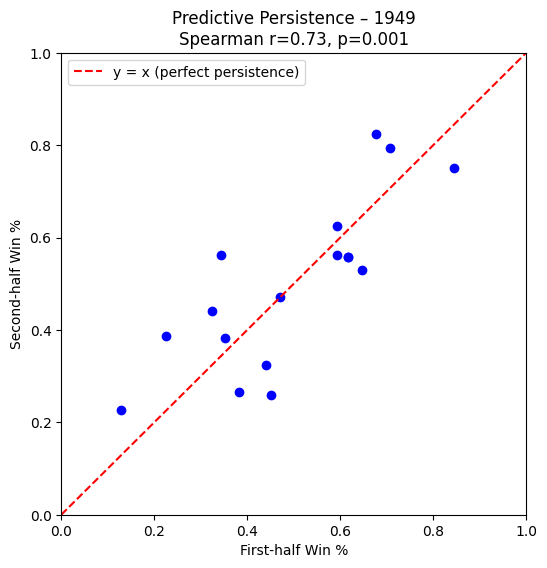

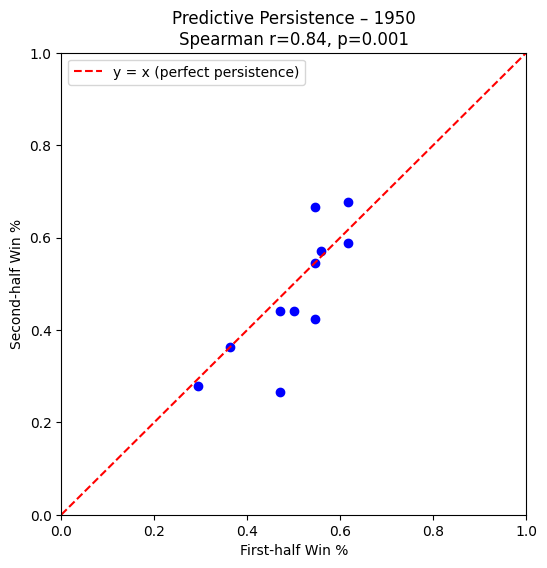

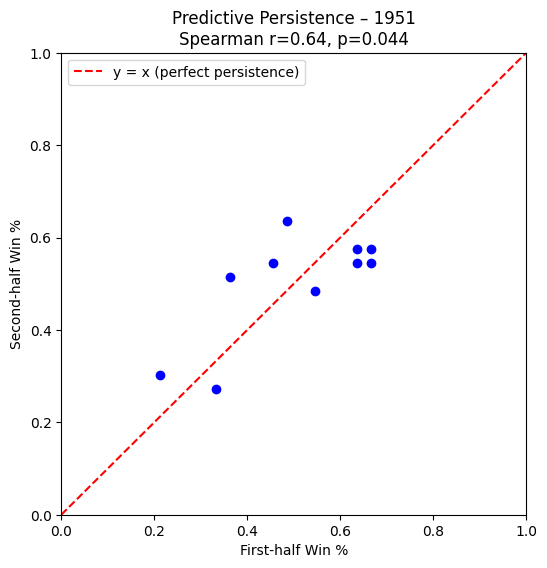

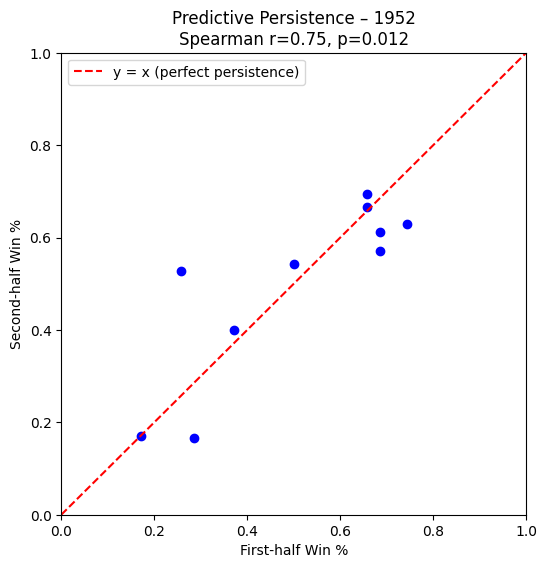

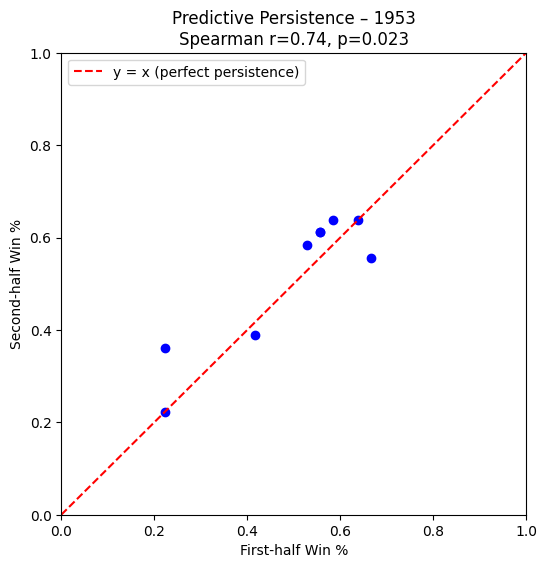

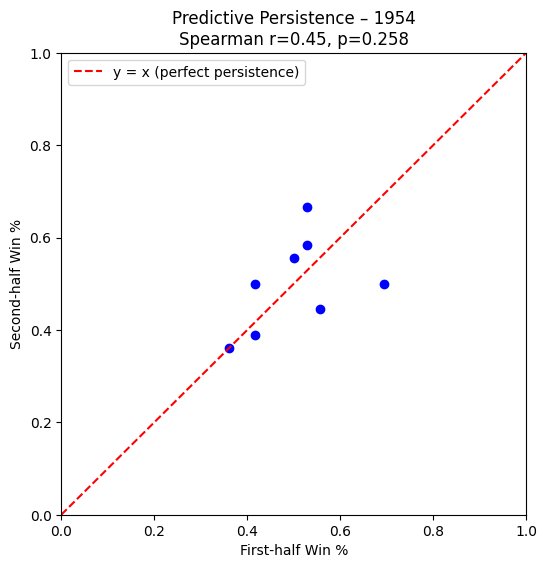

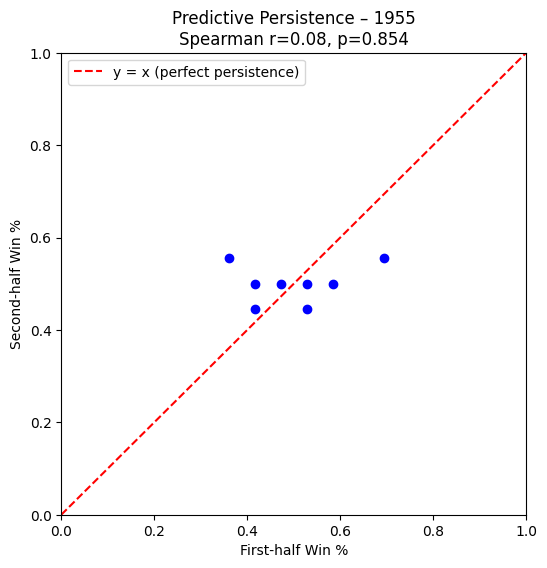

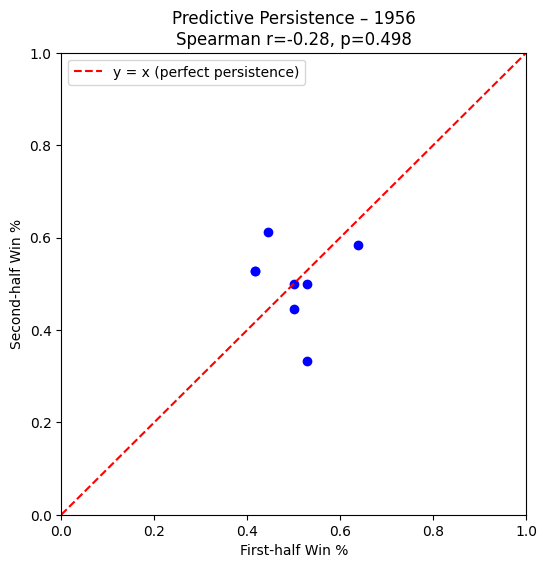

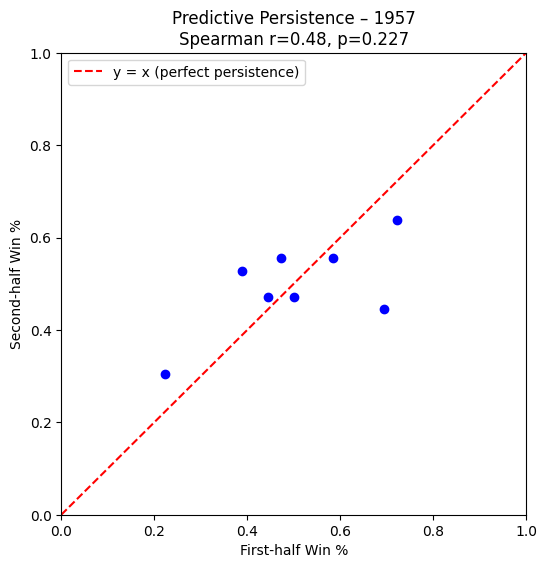

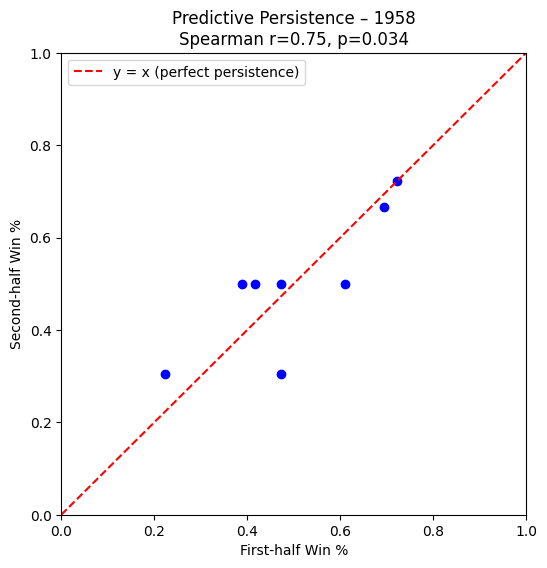

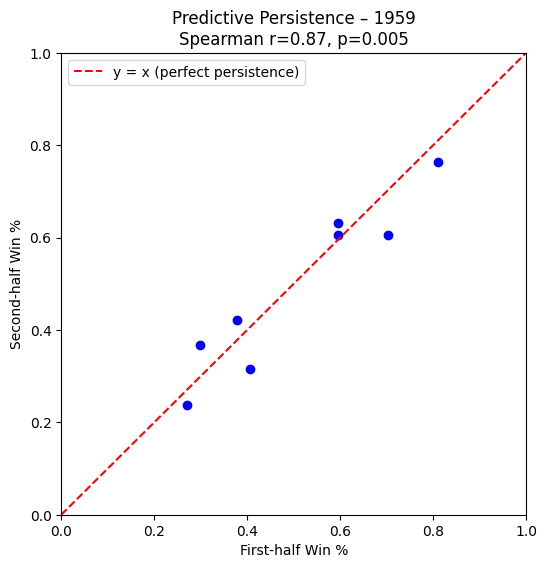

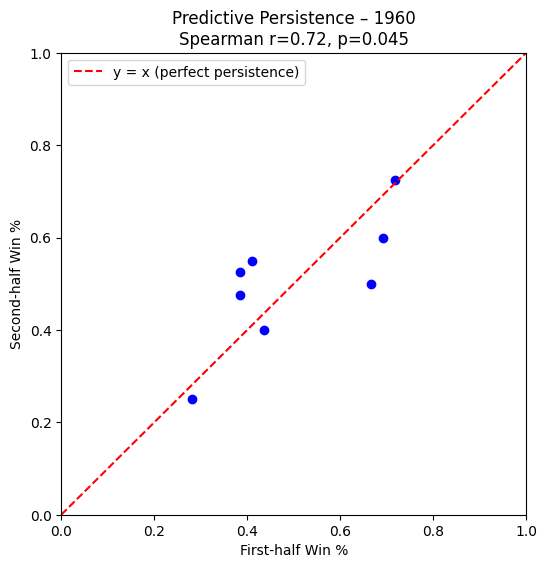

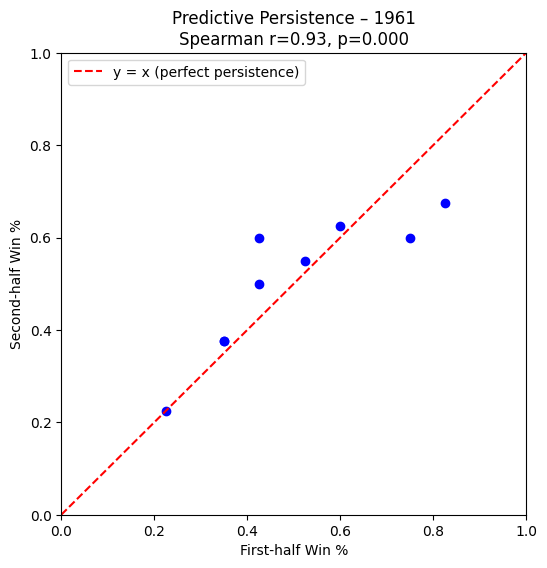

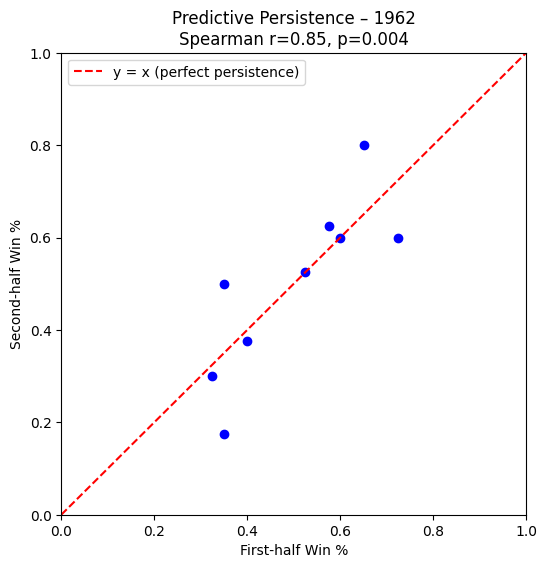

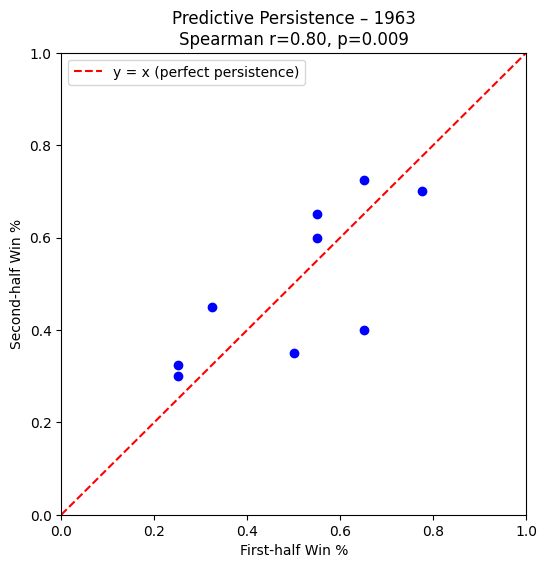

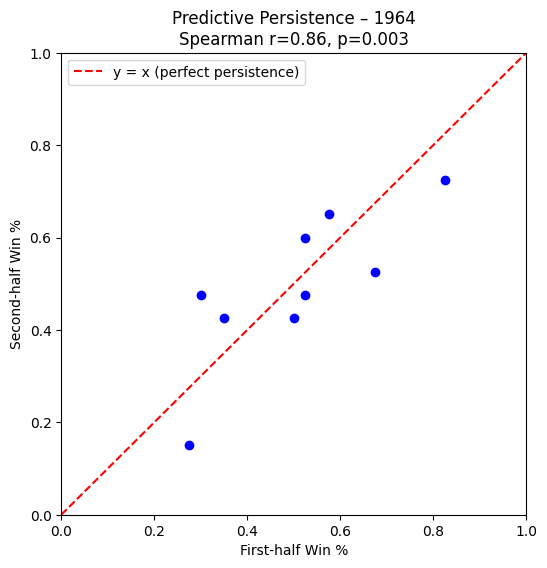

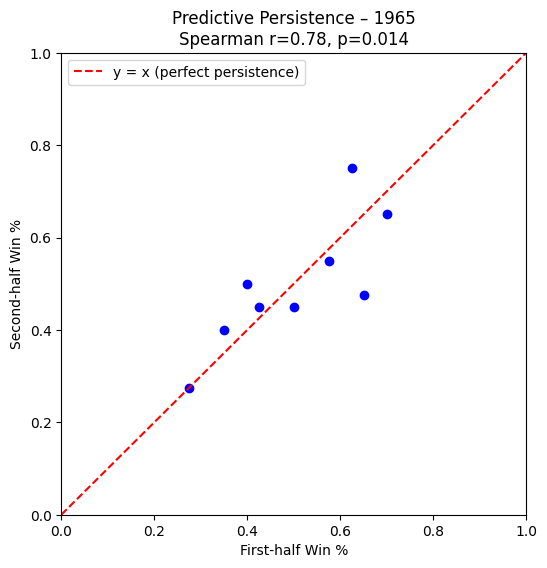

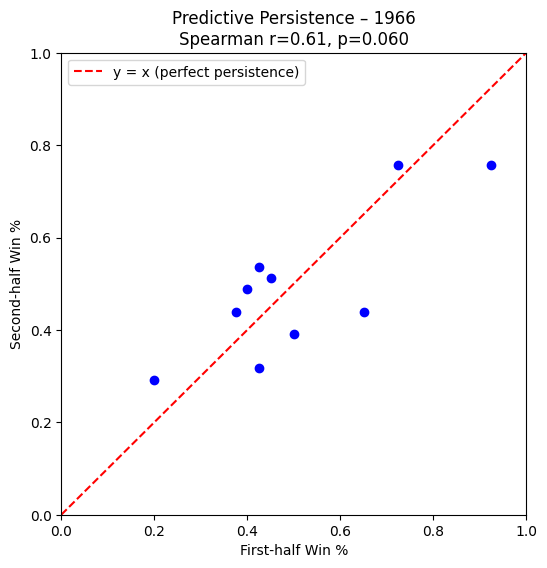

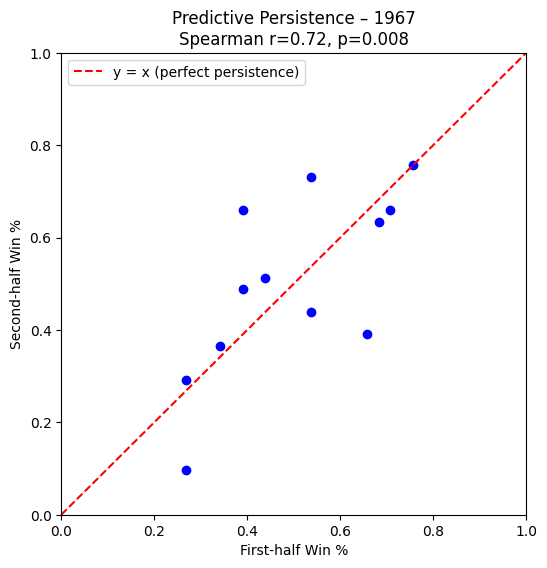

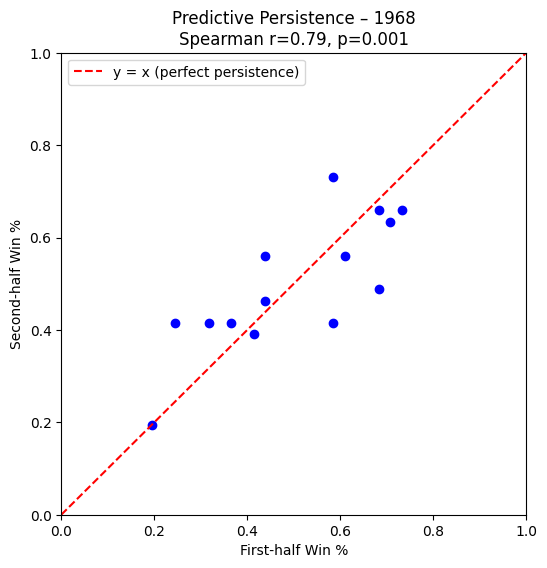

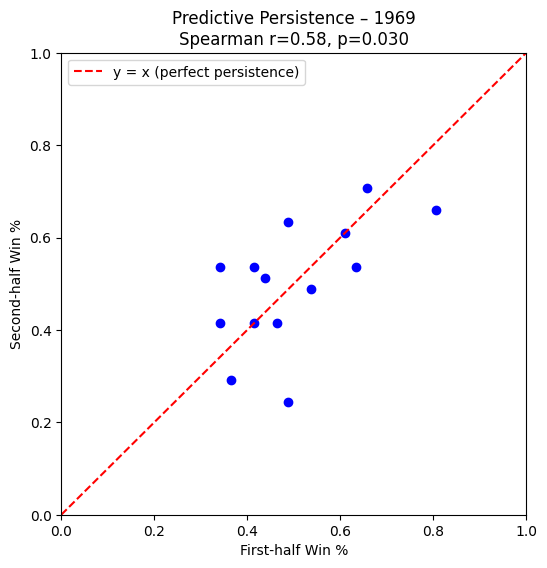

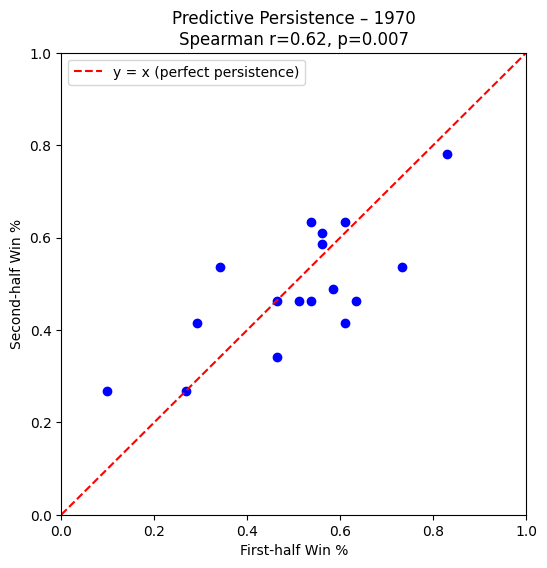

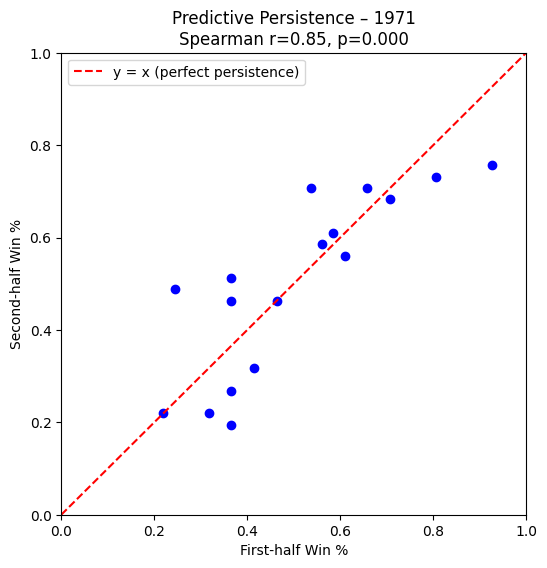

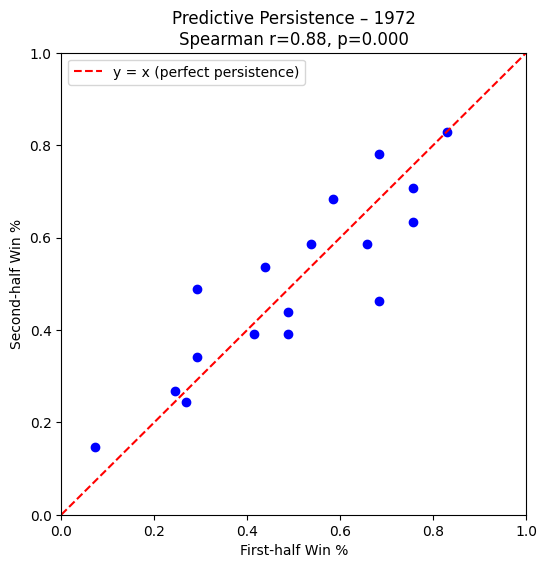

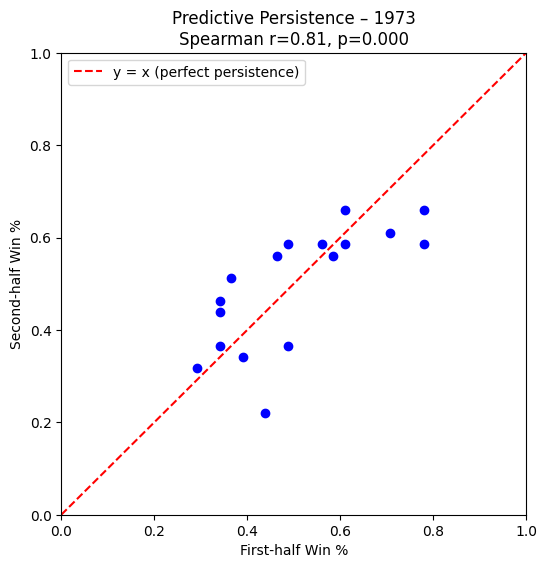

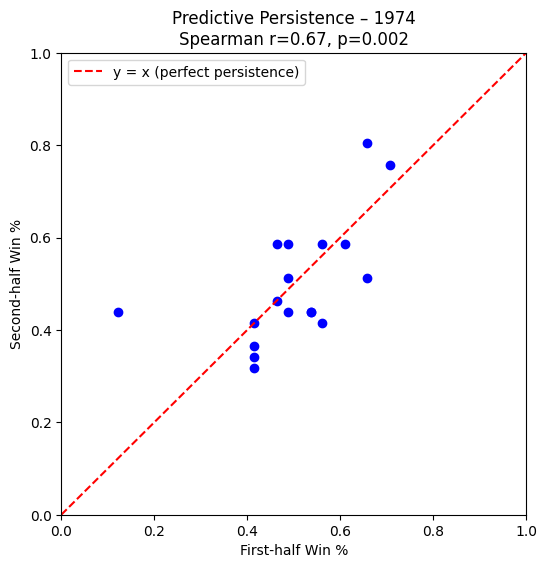

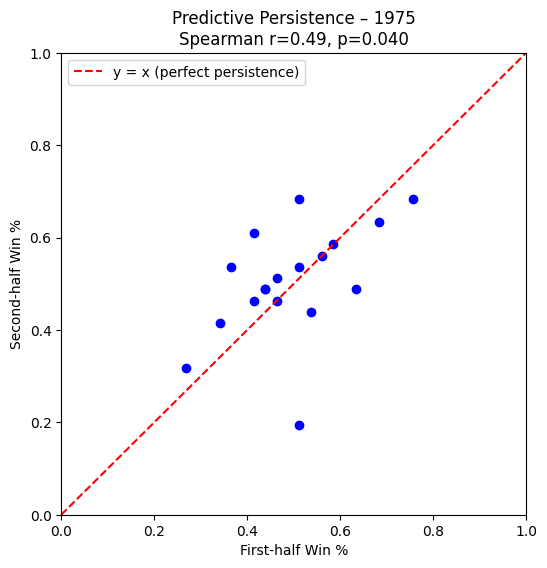

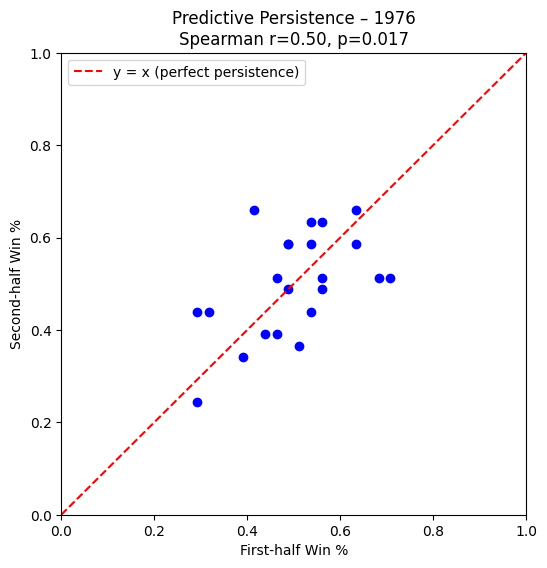

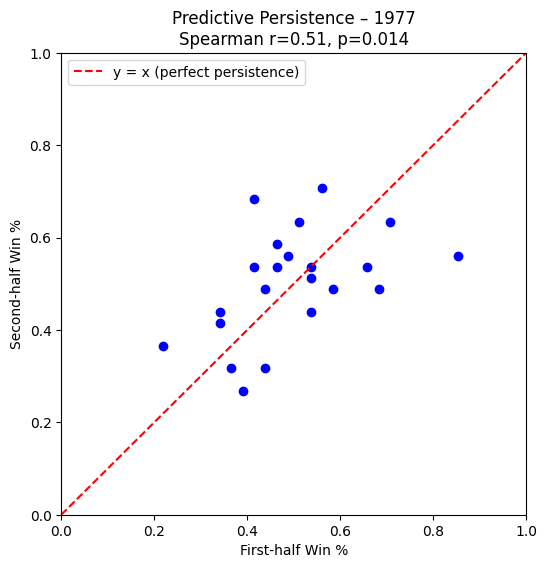

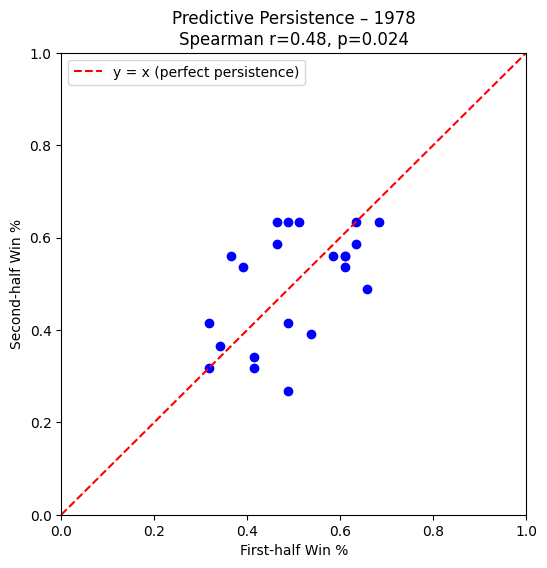

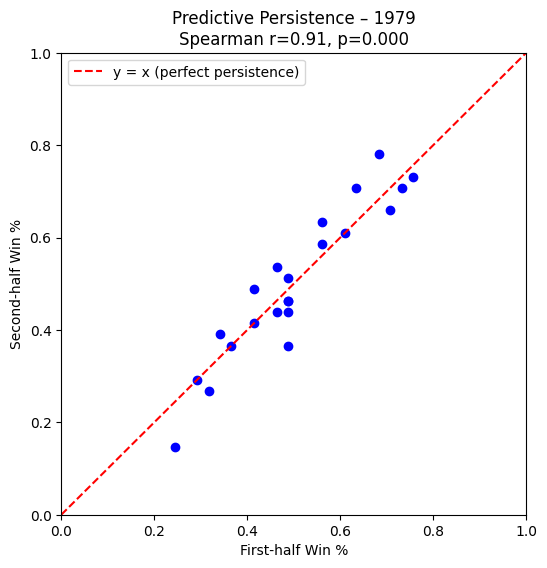

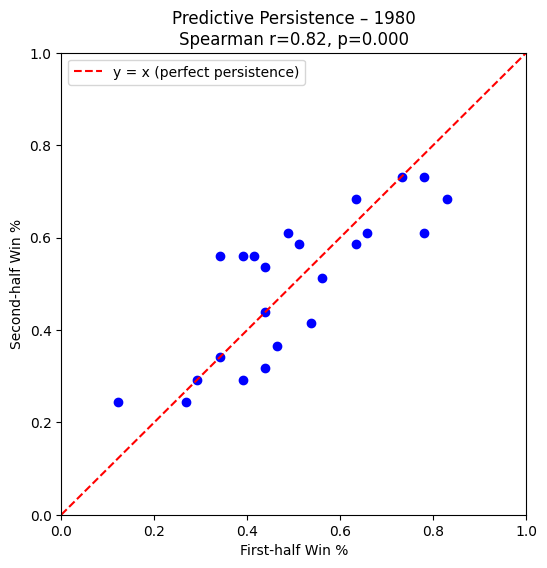

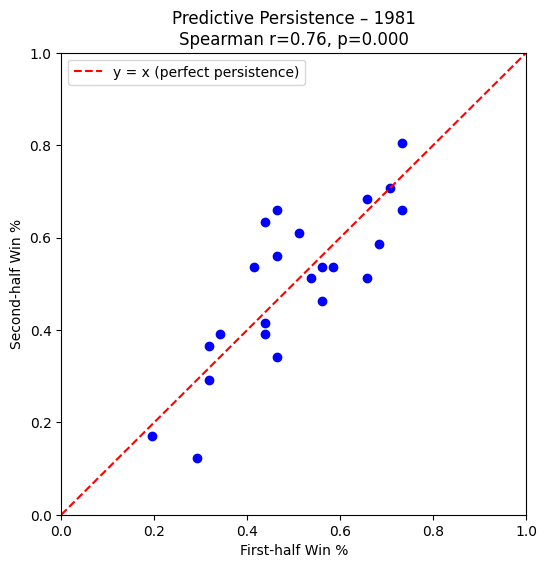

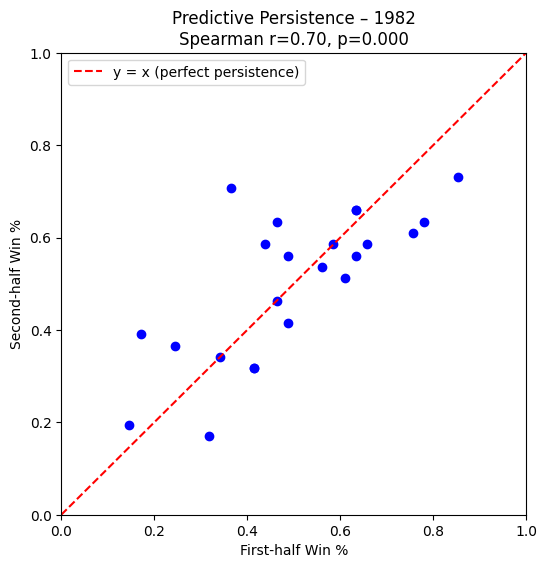

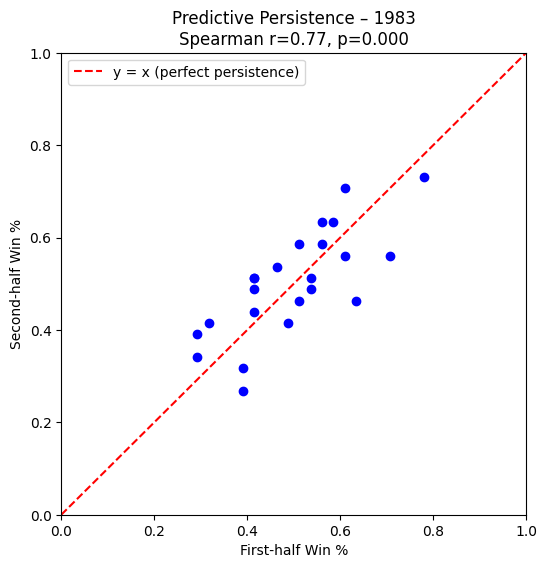

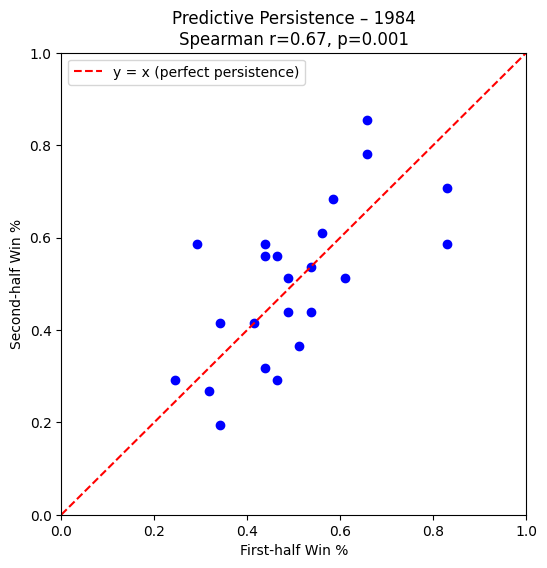

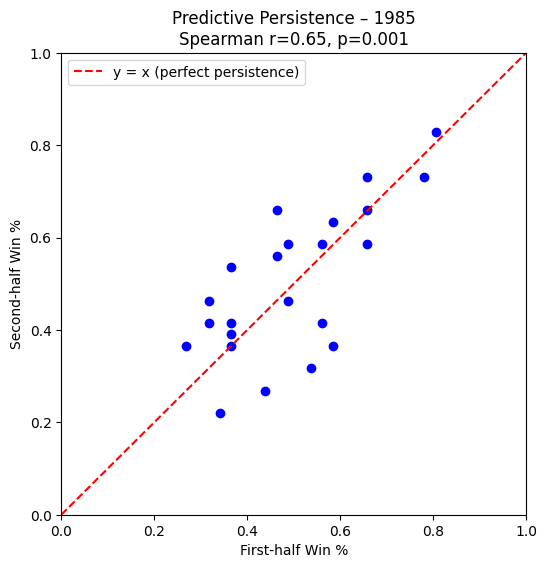

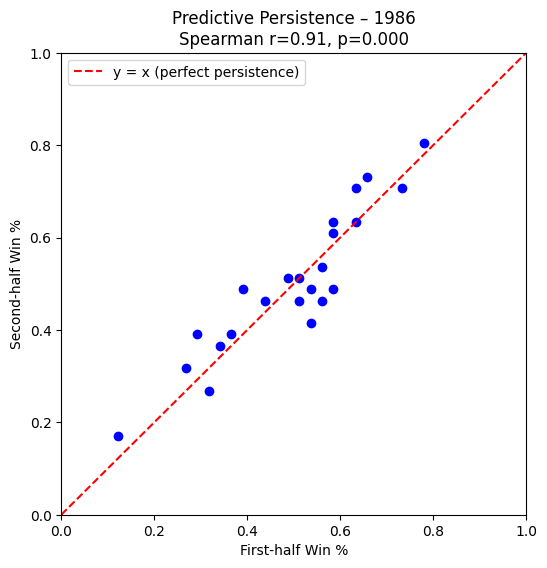

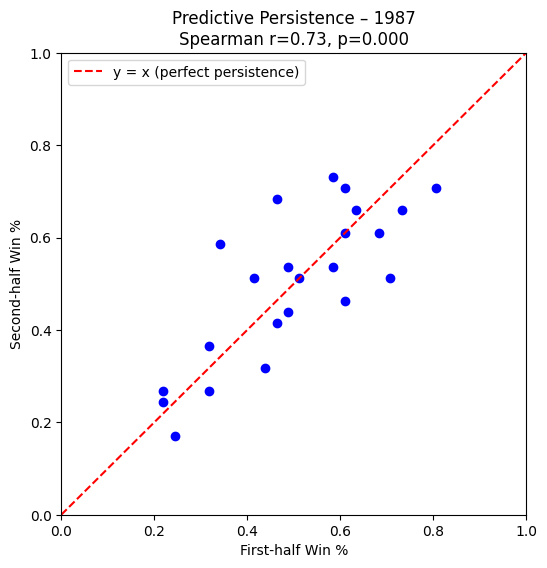

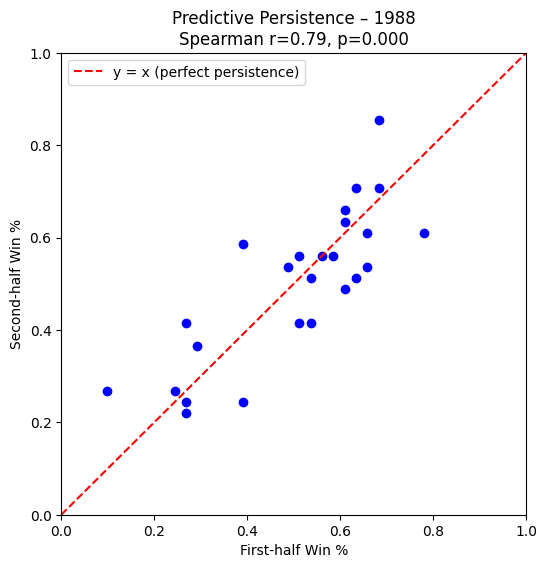

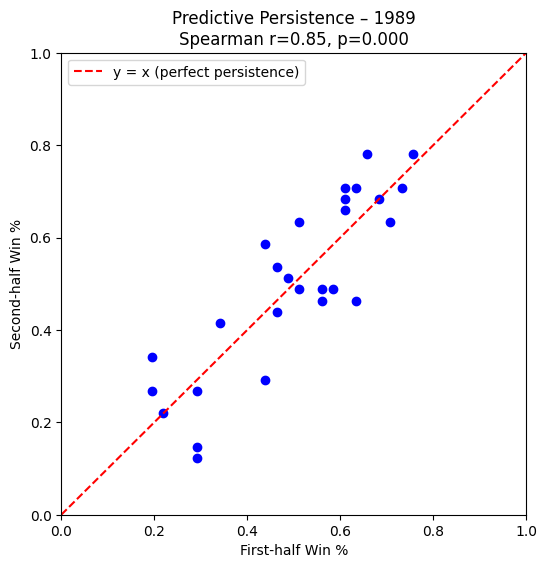

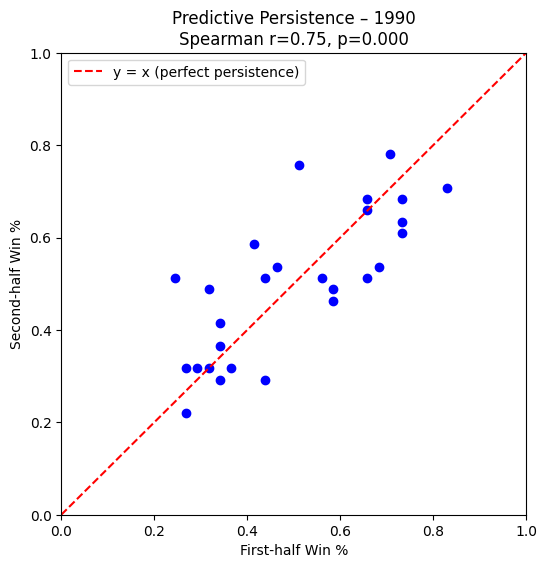

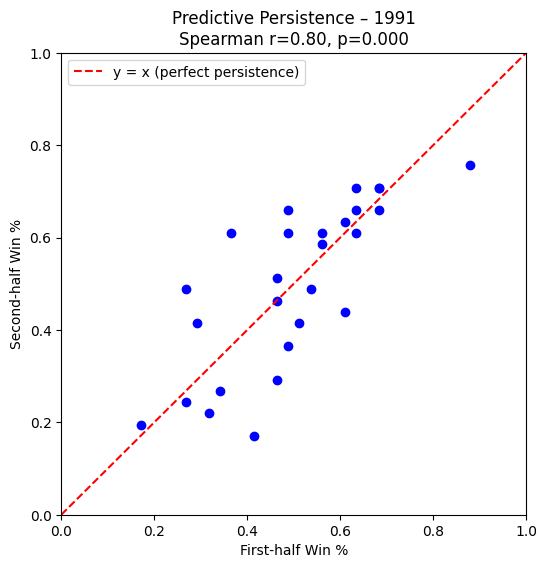

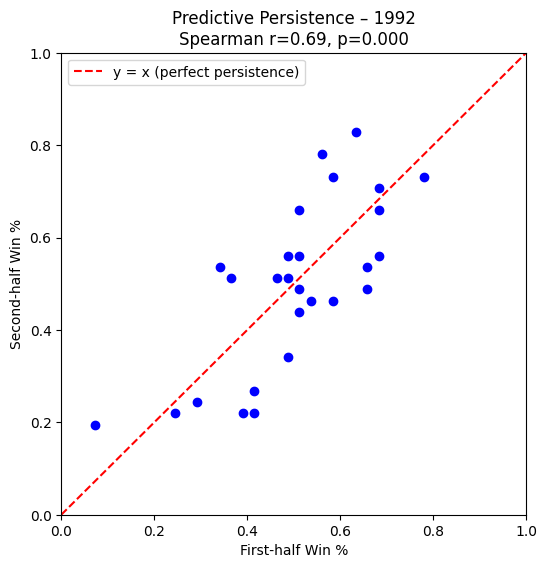

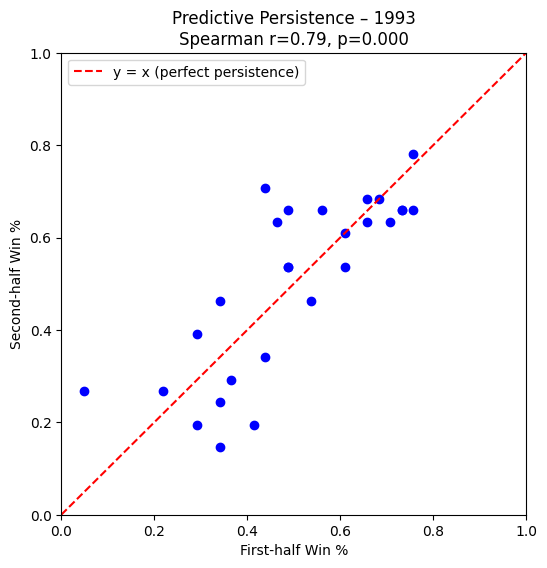

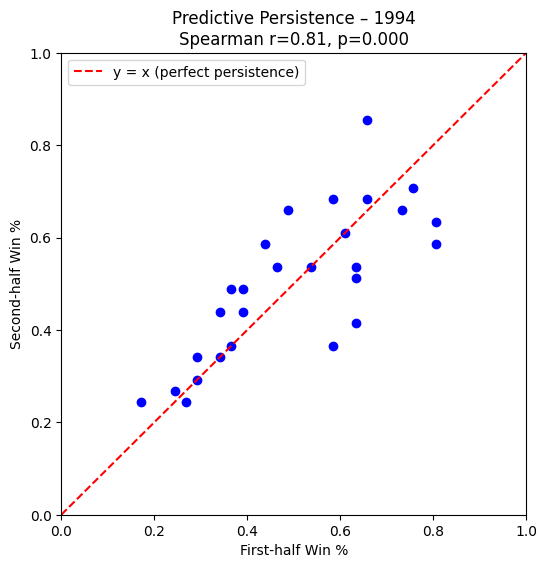

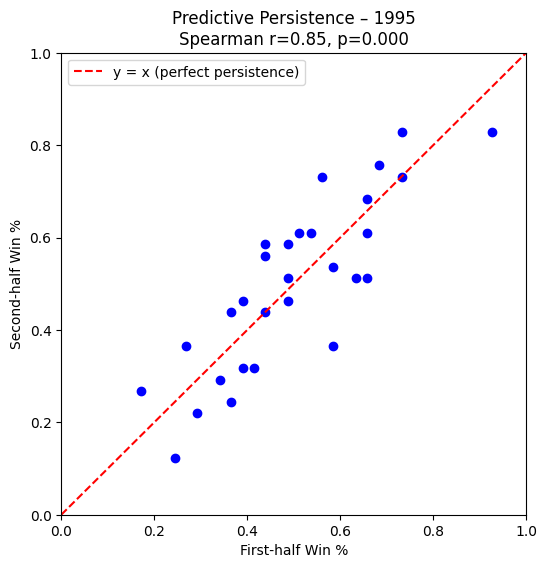

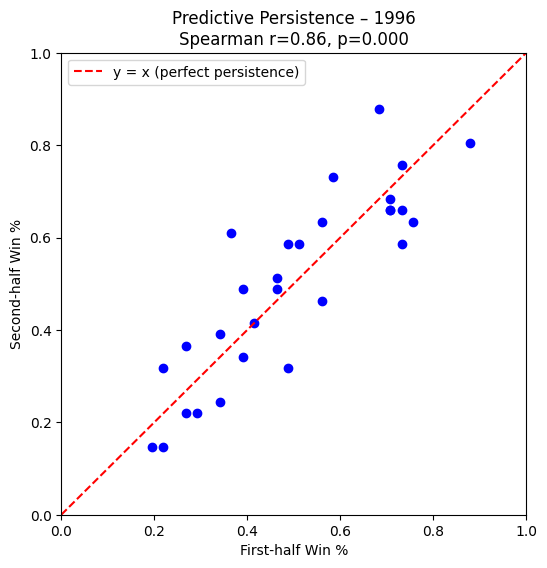

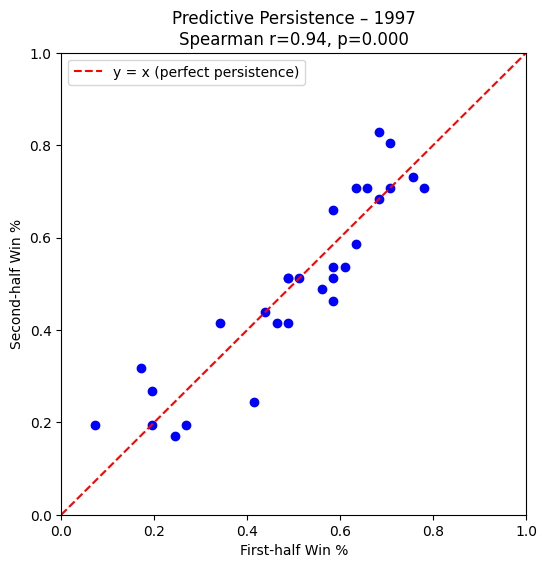

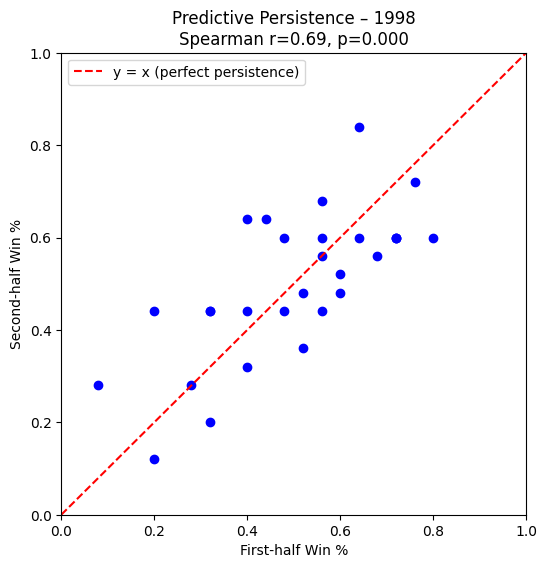

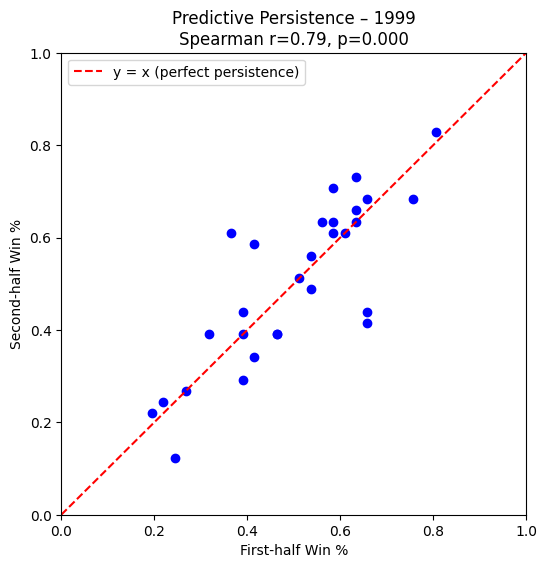

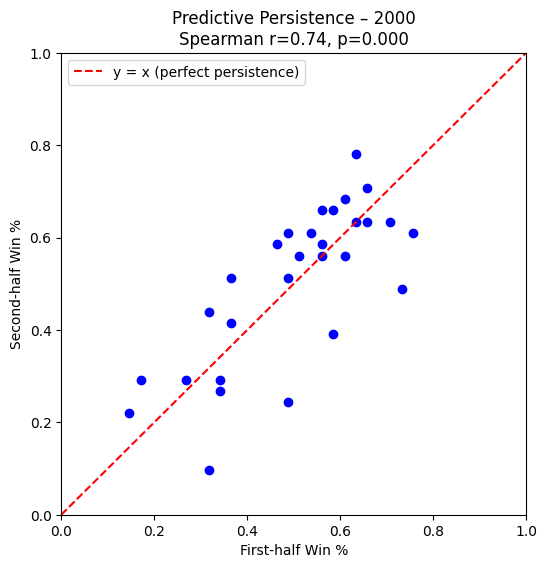

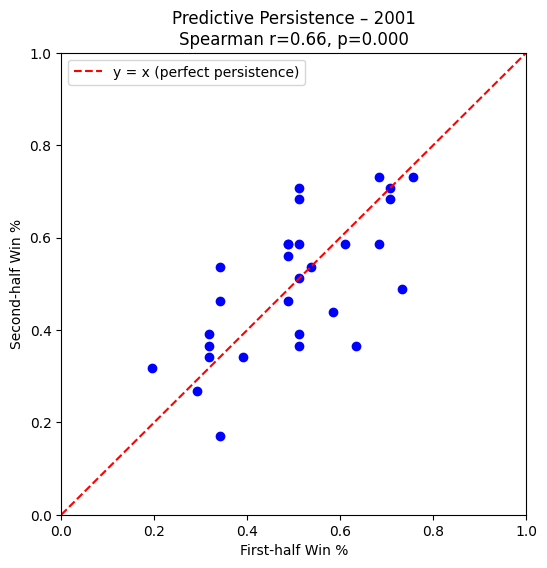

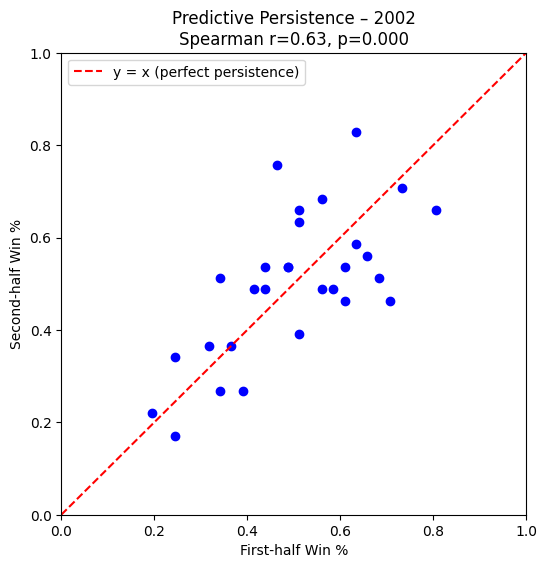

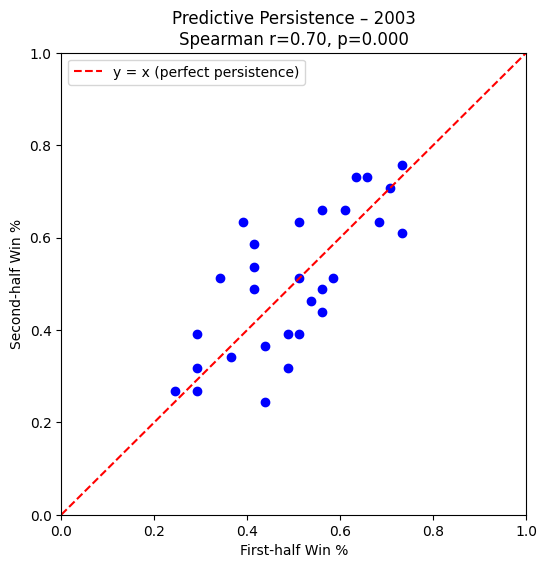

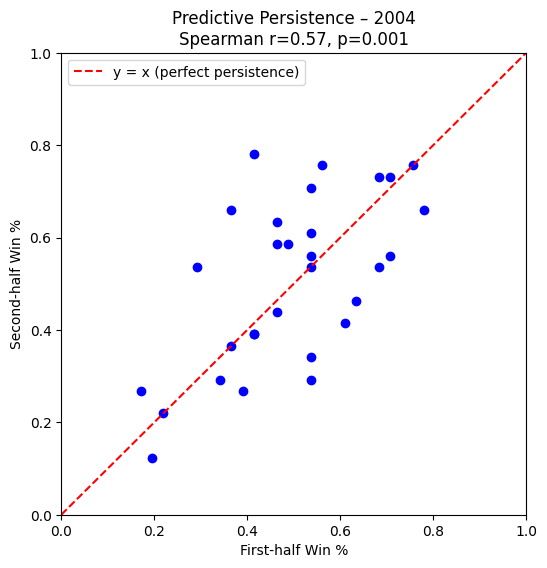

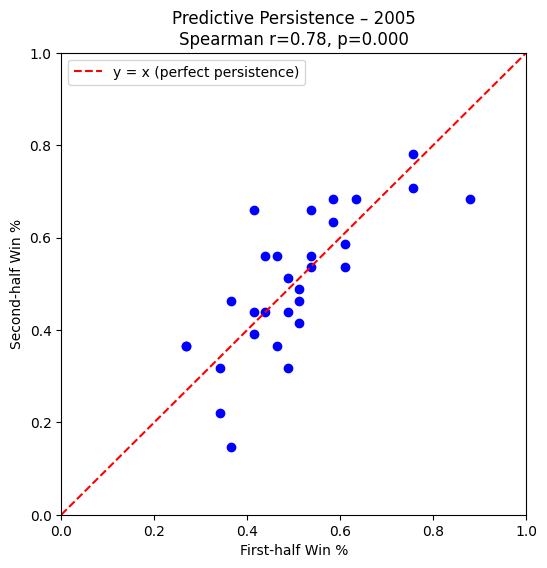

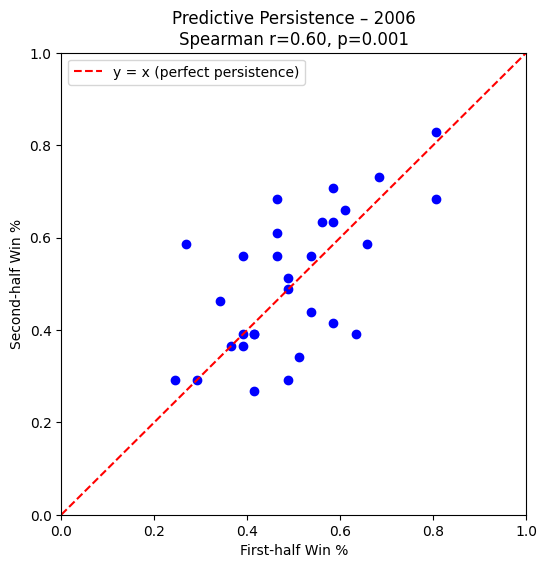

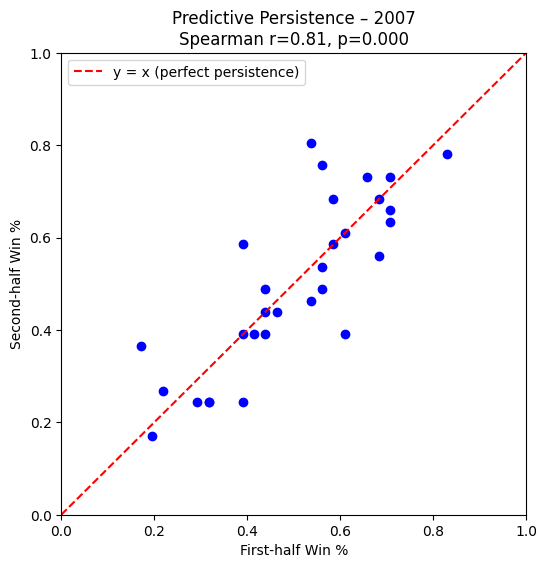

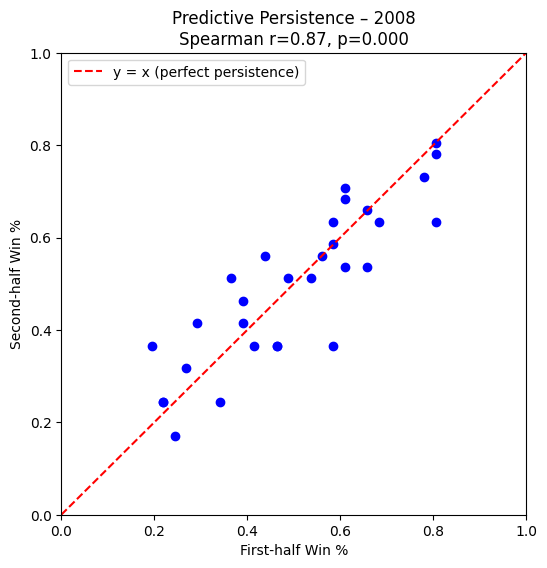

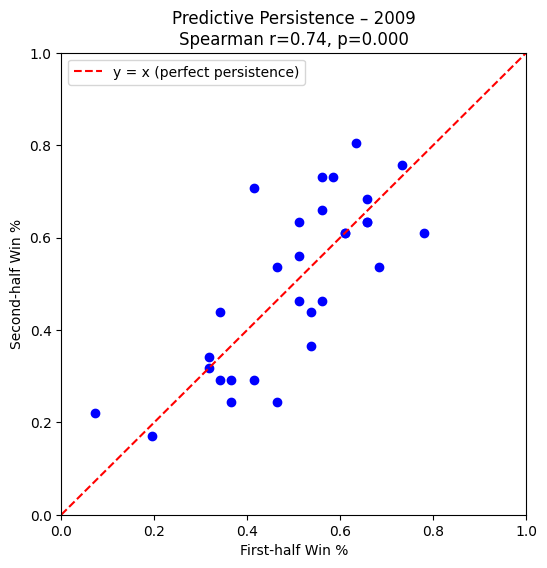

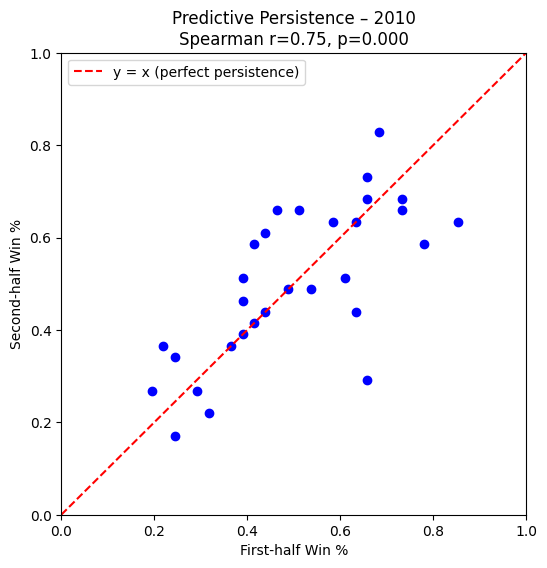

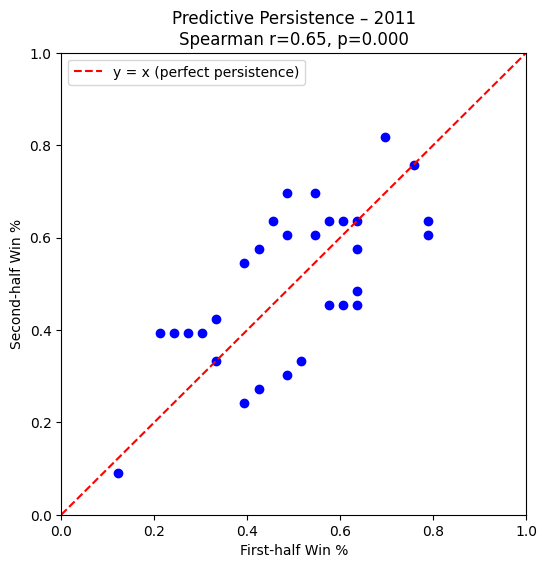

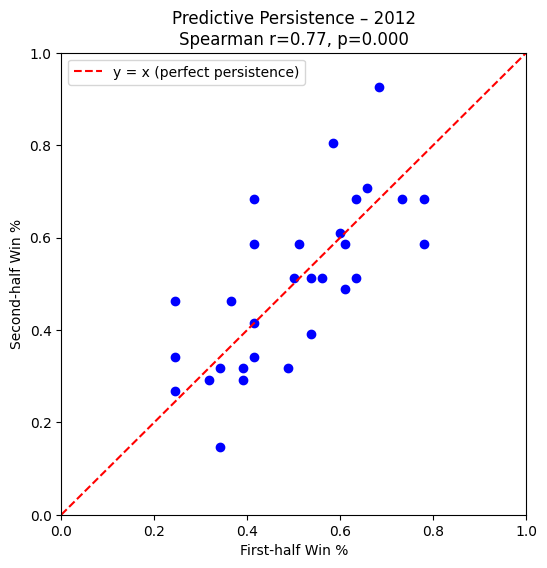

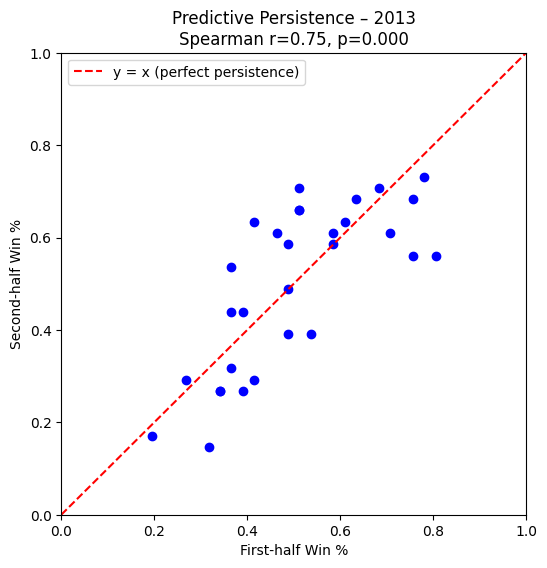

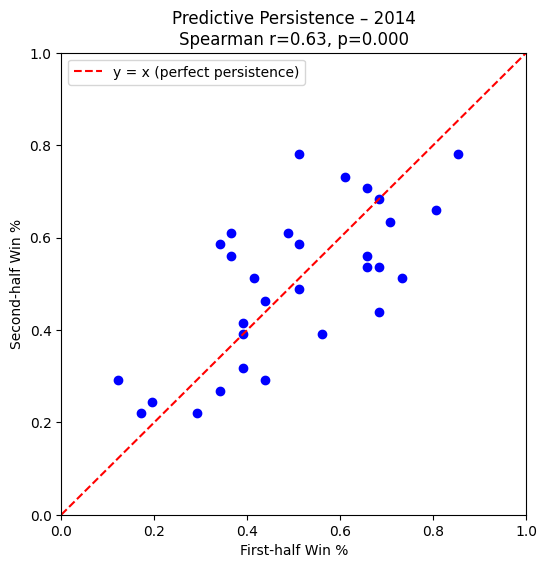

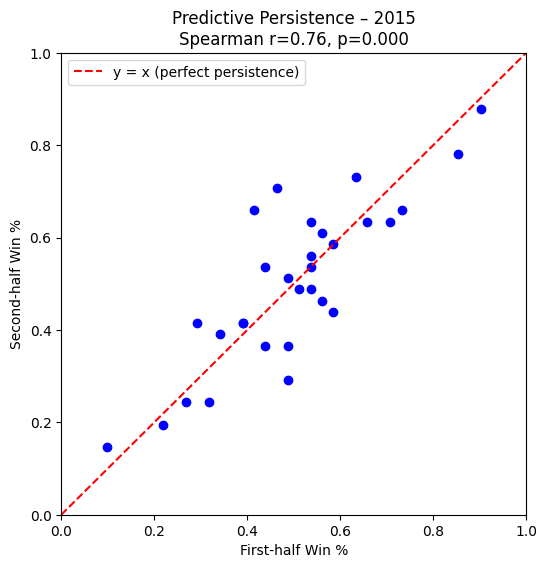

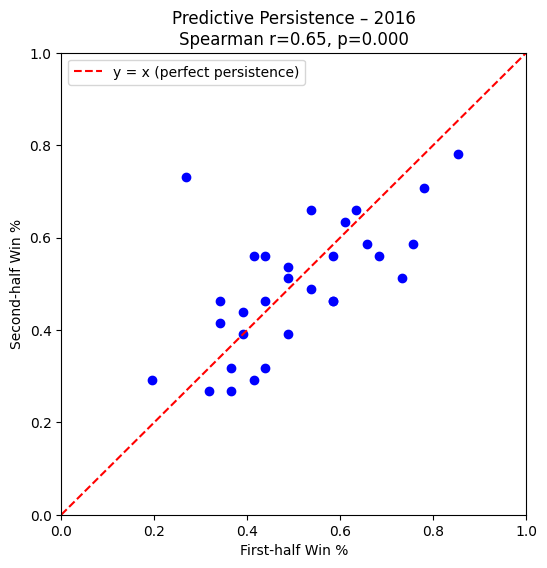

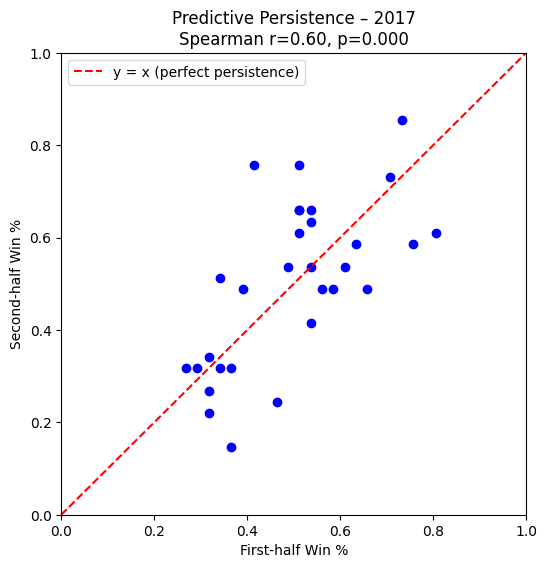

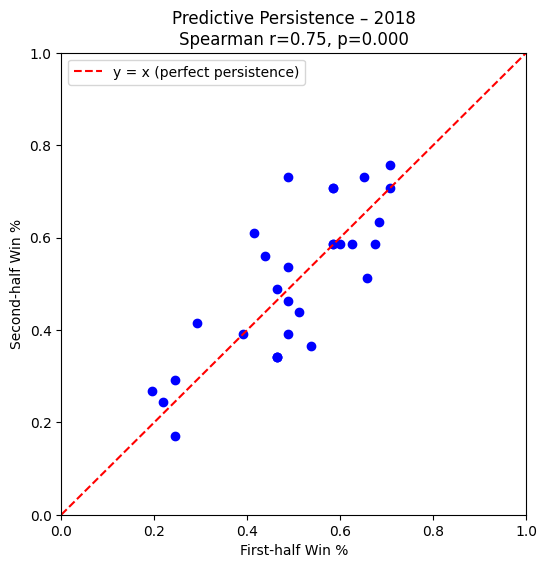

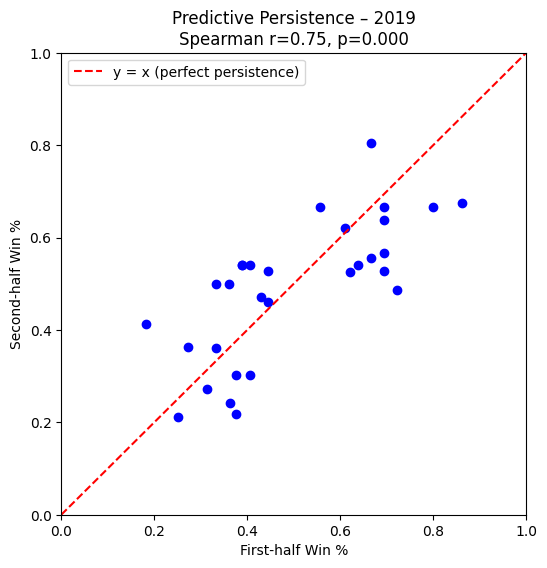

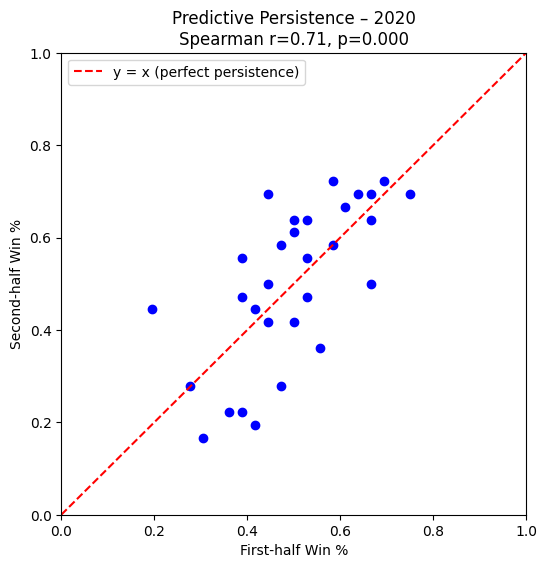

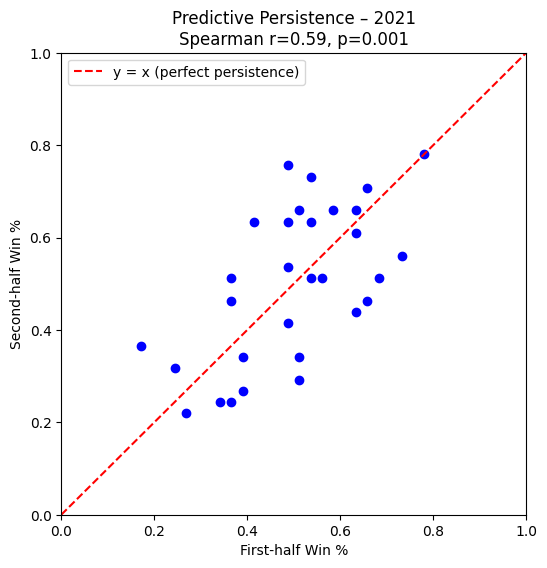

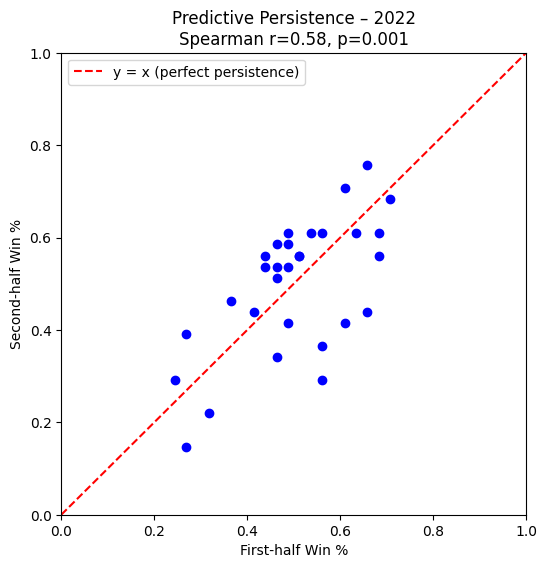

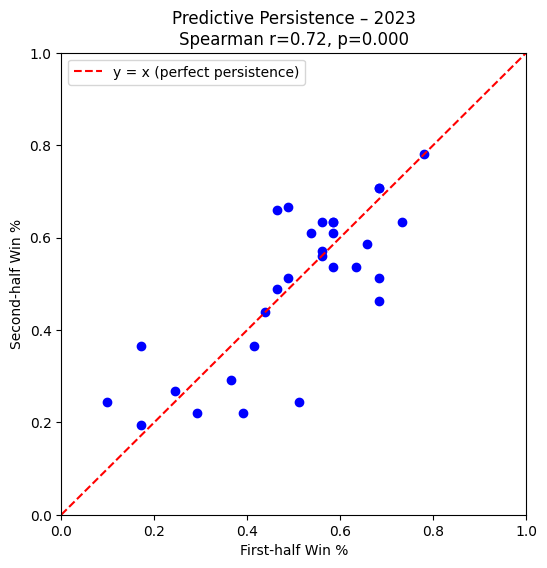

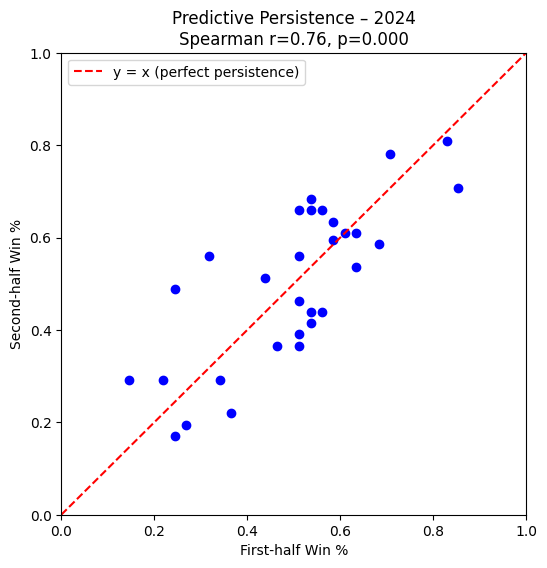

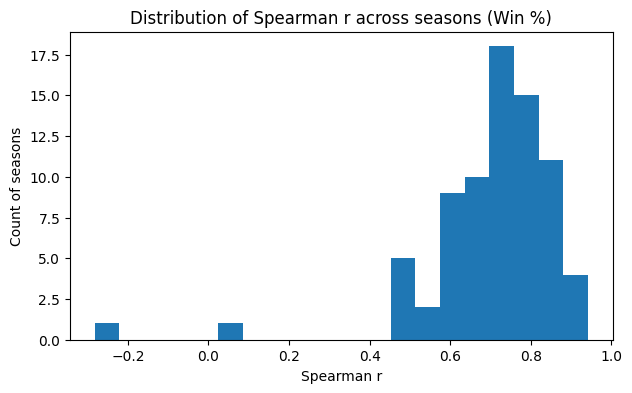

Saved CSVs for later use.


In [2]:
# ============================================================
# Predictive Persistence Analysis (NBA dataset)
# ============================================================

# 0) Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Make pandas show more rows/cols if needed
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 50)

# ------------------------------------------------------------
# 1) Load the dataset

DATA_PATH = 'nba_data.csv'

# Load
df = pd.read_csv(DATA_PATH)

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

print("Raw data shape:", df.shape)
display(df.head())

# ------------------------------------------------------------
# 2) Convert into "team-game" format
# ------------------------------------------------------------
# Each row in original = one game (team1 vs team2)
# We want two rows per game: one per team’s perspective

# Team1 perspective
t1 = pd.DataFrame({
    'season': df['season'],
    'date': df['date'],
    'team': df['team1'],
    'opponent': df['team2'],
    'points_for': df['score1'],
    'points_against': df['score2'],
    'home': (df['home_away'] == 1).astype(int),   # 1 if team1 was home
})
t1['margin'] = t1['points_for'] - t1['points_against']
t1['win'] = (t1['margin'] > 0).astype(int)

# Team2 perspective
t2 = pd.DataFrame({
    'season': df['season'],
    'date': df['date'],
    'team': df['team2'],
    'opponent': df['team1'],
    'points_for': df['score2'],
    'points_against': df['score1'],
    'home': (df['home_away'] == 0).astype(int),   # if team1 is home, then team2 is away
})
t2['margin'] = t2['points_for'] - t2['points_against']
t2['win'] = (t2['margin'] > 0).astype(int)

# Combine both perspectives
team_games = pd.concat([t1, t2], ignore_index=True)
team_games = team_games.sort_values(['season','team','date']).reset_index(drop=True)

print("Team-game tidy data shape:", team_games.shape)
display(team_games.head())

# ------------------------------------------------------------
# 3) Define helper functions
# ------------------------------------------------------------
def compute_first_second_halves(team_games, metric='win'):
    """
    For each team-season:
    - Sort games by date
    - Split into first half and second half
    - Compute average metric in each half (Win% or Point Differential)
    Returns: DataFrame with one row per team-season
    """
    rows = []
    for (season, team), grp in team_games.groupby(['season','team']):
        grp = grp.sort_values('date')
        n = len(grp)
        if n < 2:  # skip teams with less than 2 games
            continue
        split = n // 2  # how many games go in the first half
        first = grp.iloc[:split]
        second = grp.iloc[split:]
        if len(first) == 0 or len(second) == 0:
            continue

        if metric == 'win':
            m1, m2 = first['win'].mean(), second['win'].mean()
        elif metric == 'margin':
            m1, m2 = first['margin'].mean(), second['margin'].mean()
        else:
            raise ValueError('metric must be "win" or "margin"')

        rows.append({'season': season, 'team': team,
                     'first': m1, 'second': m2,
                     'n_games': n})
    return pd.DataFrame(rows)

def season_correlations(first_second_df):
    """
    For each season:
    - Compute correlation between first-half and second-half values across teams
    - Both Spearman (rank-based) and Pearson (linear) correlations
    Returns: DataFrame of correlations per season
    """
    out = []
    for season, grp in first_second_df.groupby('season'):
        if grp['first'].nunique() <= 1 or grp['second'].nunique() <= 1 or len(grp) < 3:
            # not enough variance/teams
            continue
        r_s, p_s = stats.spearmanr(grp['first'], grp['second'])
        r_p, p_p = stats.pearsonr(grp['first'], grp['second'])
        out.append({'season': season, 'n_teams': len(grp),
                    'spearman_r': r_s, 'spearman_p': p_s,
                    'pearson_r': r_p, 'pearson_p': p_p})
    return pd.DataFrame(out).sort_values('season')

def plot_season_scatter(grp, season, metric_name='Win %'):
    """
    Scatterplot for one season:
    - X = first-half metric
    - Y = second-half metric
    - Red dashed line = perfect persistence (y=x)
    - Title shows Spearman correlation
    """
    r_s, p_s = stats.spearmanr(grp['first'], grp['second'])
    plt.figure(figsize=(6,6))
    plt.scatter(grp['first'], grp['second'], color='blue')
    xs = np.linspace(0, 1 if metric_name=='Win %' else grp[['first','second']].values.max(), 100)
    plt.plot(xs, xs, linestyle='--', color='red', label='y = x (perfect persistence)')
    if metric_name == 'Win %':
        plt.xlim(0, 1)
        plt.ylim(0, 1)
    plt.xlabel(f'First-half {metric_name}')
    plt.ylabel(f'Second-half {metric_name}')
    plt.title(f'Predictive Persistence – {season}\nSpearman r={r_s:.2f}, p={p_s:.3f}')
    plt.legend()
    plt.show()

# ------------------------------------------------------------
# 4) Run predictive persistence analysis
# ------------------------------------------------------------
# Compute first/second-half metrics
fs_win = compute_first_second_halves(team_games, metric='win')
fs_margin = compute_first_second_halves(team_games, metric='margin')

print("Sample (Win% first vs second half):")
display(fs_win.head())

# Compute correlations for all seasons
corr_win = season_correlations(fs_win)
corr_margin = season_correlations(fs_margin)

print("Win% correlations by season:")
display(corr_win)

print("Point Differential correlations by season:")
display(corr_margin)

# ------------------------------------------------------------
# 5) Plot scatterplots for ALL seasons (loop)
# ------------------------------------------------------------
for season, grp in fs_win.groupby('season'):
    if len(grp) >= 3:  # only plot if at least 3 teams
        plot_season_scatter(grp, season, metric_name='Win %')

# ------------------------------------------------------------
# 6) Summarize across seasons
# ------------------------------------------------------------
# Histogram of Spearman correlations across seasons (Win%)
if not corr_win.empty:
    plt.figure(figsize=(7,4))
    plt.hist(corr_win['spearman_r'].dropna(), bins=20)
    plt.title('Distribution of Spearman r across seasons (Win %)')
    plt.xlabel('Spearman r')
    plt.ylabel('Count of seasons')
    plt.show()

# save correlation tables
corr_win.to_csv('predictive_persistence_correlations_win.csv', index=False)
corr_margin.to_csv('predictive_persistence_correlations_margin.csv', index=False)


In [4]:
import os

# Make sure the folder exists (will be created in working dir, same place as your CSVs)
os.makedirs("figures_win", exist_ok=True)

def plot_season_scatter(grp, season):
    """
    Scatterplot for one season (Win%), saved into ./figures_win/
    """
    r_s, p_s = stats.spearmanr(grp['first'], grp['second'])
    plt.figure(figsize=(6,6))
    plt.scatter(grp['first'], grp['second'], color='blue')

    # Red dashed line = perfect persistence
    xs = np.linspace(0, 1, 100)
    plt.plot(xs, xs, linestyle='--', color='red', label='y = x (perfect persistence)')

    # Axis + labels
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel('First-half Win %')
    plt.ylabel('Second-half Win %')
    plt.title(f'Predictive Persistence – {season}\nSpearman r={r_s:.2f}, p={p_s:.3f}')
    plt.legend()

    # Save file into figures_win folder
    fname = f"figures_win/{season}_win_pct.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Saved: {fname}")

# Loop: save one figure per season (Win% only)
for season, grp in fs_win.groupby('season'):
    if len(grp) >= 3:
        plot_season_scatter(grp, season)


Saved: figures_win/1949_win_pct.png
Saved: figures_win/1950_win_pct.png
Saved: figures_win/1951_win_pct.png
Saved: figures_win/1952_win_pct.png
Saved: figures_win/1953_win_pct.png
Saved: figures_win/1954_win_pct.png
Saved: figures_win/1955_win_pct.png
Saved: figures_win/1956_win_pct.png
Saved: figures_win/1957_win_pct.png
Saved: figures_win/1958_win_pct.png
Saved: figures_win/1959_win_pct.png
Saved: figures_win/1960_win_pct.png
Saved: figures_win/1961_win_pct.png
Saved: figures_win/1962_win_pct.png
Saved: figures_win/1963_win_pct.png
Saved: figures_win/1964_win_pct.png
Saved: figures_win/1965_win_pct.png
Saved: figures_win/1966_win_pct.png
Saved: figures_win/1967_win_pct.png
Saved: figures_win/1968_win_pct.png
Saved: figures_win/1969_win_pct.png
Saved: figures_win/1970_win_pct.png
Saved: figures_win/1971_win_pct.png
Saved: figures_win/1972_win_pct.png
Saved: figures_win/1973_win_pct.png
Saved: figures_win/1974_win_pct.png
Saved: figures_win/1975_win_pct.png
Saved: figures_win/1976_win_

In [5]:
# Download files
!zip -r figures_win.zip figures_win


from google.colab import files
files.download("figures_win.zip")


  adding: figures_win/ (stored 0%)
  adding: figures_win/2016_win_pct.png (deflated 9%)
  adding: figures_win/1972_win_pct.png (deflated 9%)
  adding: figures_win/1953_win_pct.png (deflated 9%)
  adding: figures_win/2010_win_pct.png (deflated 8%)
  adding: figures_win/1949_win_pct.png (deflated 9%)
  adding: figures_win/1967_win_pct.png (deflated 9%)
  adding: figures_win/1956_win_pct.png (deflated 9%)
  adding: figures_win/1995_win_pct.png (deflated 9%)
  adding: figures_win/2009_win_pct.png (deflated 9%)
  adding: figures_win/1992_win_pct.png (deflated 9%)
  adding: figures_win/1957_win_pct.png (deflated 9%)
  adding: figures_win/1989_win_pct.png (deflated 9%)
  adding: figures_win/1966_win_pct.png (deflated 9%)
  adding: figures_win/1990_win_pct.png (deflated 9%)
  adding: figures_win/1993_win_pct.png (deflated 9%)
  adding: figures_win/2000_win_pct.png (deflated 9%)
  adding: figures_win/2012_win_pct.png (deflated 9%)
  adding: figures_win/1974_win_pct.png (deflated 9%)
  adding: f

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Overall upset frequency: 32.68%
   season     upset
0    1949  0.290553
1    1950  0.395480
2    1951  0.387879
3    1952  0.284091
4    1953  0.342593


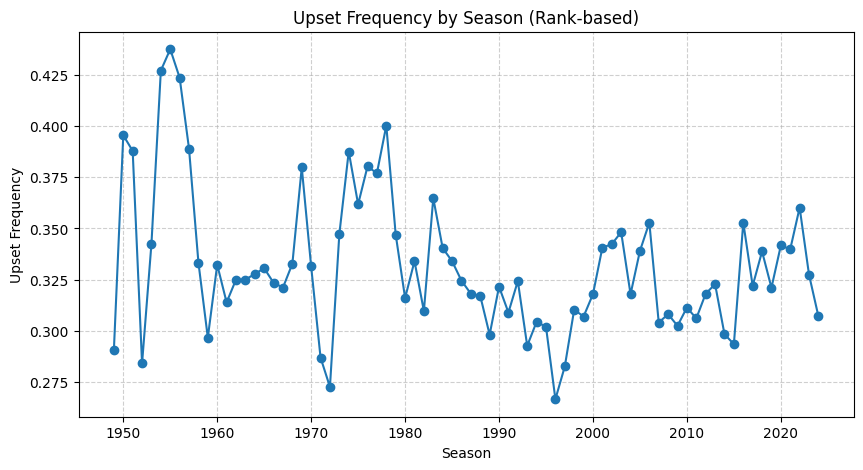

Saved upset_frequency_by_season.csv


In [6]:
# ================================
# Upset Frequency Analysis (by rank)
# ================================

import pandas as pd
import matplotlib.pyplot as plt

# 1. Load both datasets
games = pd.read_csv("nba_data.csv")
season_summary = pd.read_csv("end_of_season_nba.csv")

# Convert dates
games['date'] = pd.to_datetime(games['date'])

# 2. Determine winner for each game
games['team1_won'] = (games['score1'] > games['score2']).astype(int)

# 3. Merge end-of-season rank for both teams
games = games.merge(
    season_summary[['season','team_id','rank']],
    left_on=['season','team1'], right_on=['season','team_id'],
    how='left'
).rename(columns={'rank':'team1_rank'}).drop(columns=['team_id'])

games = games.merge(
    season_summary[['season','team_id','rank']],
    left_on=['season','team2'], right_on=['season','team_id'],
    how='left'
).rename(columns={'rank':'team2_rank'}).drop(columns=['team_id'])

# 4. Define upset
def is_upset(row):
    if row['team1_won'] == 1:  # team1 won
        return row['team1_rank'] > row['team2_rank']  # upset if worse rank won
    else:                      # team2 won
        return row['team2_rank'] > row['team1_rank']

games['upset'] = games.apply(is_upset, axis=1).astype(int)

# 5. Overall upset frequency
overall_upset_rate = games['upset'].mean()
print(f"Overall upset frequency: {overall_upset_rate:.2%}")

# 6. Upset frequency by season
upset_by_season = games.groupby('season')['upset'].mean().reset_index()
print(upset_by_season.head())

# 7. Plot upset frequency by season
plt.figure(figsize=(10,5))
plt.plot(upset_by_season['season'], upset_by_season['upset'], marker='o')
plt.title("Upset Frequency by Season (Rank-based)")
plt.xlabel("Season")
plt.ylabel("Upset Frequency")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 8. Save upset frequencies to CSV
upset_by_season.to_csv("upset_frequency_by_season.csv", index=False)
print("Saved upset_frequency_by_season.csv")
